# Análise Exploratória de Dados - Online Shoppers Purchasing Intention Dataset

**Dataset:** [Online Shoppers Purchasing Intention Dataset from UCI's](https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset)

**Objetivo:** A empresa de e-commerce precisa de um sistema preditivo para identificar a propensão de compra de um usuário baseado em seu comportamento de navegação.

## 1. Setup e Imports
Consolidação de todas as bibliotecas necessárias para a análise.

In [1]:
# Importação das bibliotecas essenciais para manipulação, análise e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ignorar avisos futuros desnecessários
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento de Dados
Leitura do dataset e visualização inicial da estrutura.

In [2]:
# Carregar dataset
df = pd.read_csv('../data/online_shoppers_intention.csv')

# Visualizar estrutura
print("=== INFORMAÇÕES DO DATASET ===")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas\n")
df.info()
print("\n=== PRIMEIRAS LINHAS ===")
display(df.head())
print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
display(df.describe().T)

=== INFORMAÇÕES DO DATASET ===
Dimensões: 12330 linhas x 18 colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region 

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



=== ESTATÍSTICAS DESCRITIVAS ===


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


## 3. Limpeza e Tratamento de Dados
**Objetivo:** Tratar problemas de integridade.

In [3]:
# Verificar valores ausentes
print("=== ANÁLISE DE VALORES AUSENTES ===")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)

if len(missing_values) > 0:
    print(missing_values)
else:
    print("Não há valores ausentes (NaN).")

# Verificar valores duplicados
print("\n=== ANÁLISE DE VALORES DUPLICADOS ===")
duplicados = df.duplicated().sum()
if duplicados > 0:
    print(f"Há {duplicados} linhas duplicadas.")
else:
    print("Não há valores duplicados.")

# Remover linhas duplicadas, se houver
if duplicados > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"Linhas duplicadas removidas. Novo tamanho do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas.")

=== ANÁLISE DE VALORES AUSENTES ===
Não há valores ausentes (NaN).

=== ANÁLISE DE VALORES DUPLICADOS ===
Há 125 linhas duplicadas.
Linhas duplicadas removidas. Novo tamanho do dataset: 12205 linhas x 18 colunas.


## 4. Análise Exploratória de Dados (EDA)
**Objetivo:** Entender características individuais de cada variável.

### **4.1. Análise da Variável Alvo (Revenue)
Identificar desbalanceamento da variável alvo, ou seja, quantas sessões resultaram em compra e quantas não.

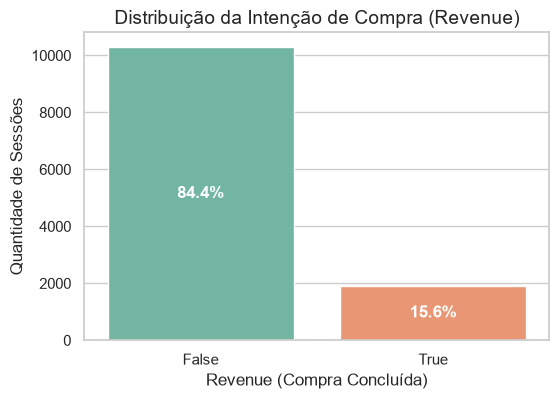

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Revenue', data=df, palette='Set2')
plt.title('Distribuição da Intenção de Compra (Revenue)')
plt.xlabel('Revenue (Compra Concluída)')
plt.ylabel('Quantidade de Sessões')

# Adicionando porcentagens no gráfico
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', weight='bold')

plt.show()

### **4.2. Comportamento de Navegação por Páginas (Administrative, Informational, ProductRelated)**
Analisando o volume de páginas visitadas e o tempo gasto nelas.

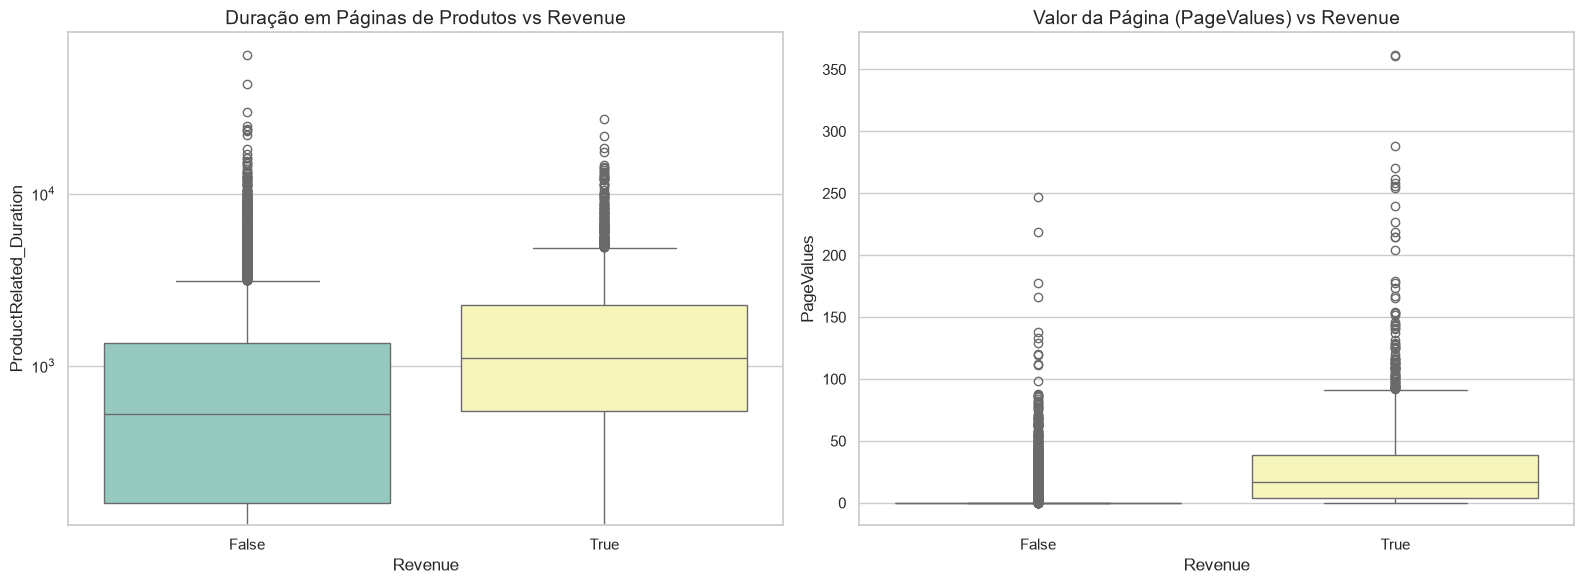

In [5]:
# Gráfico de Correlação ou Pairplot focado nas métricas de páginas e duração
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df, ax=axes[0], palette='Set3')
axes[0].set_title('Duração em Páginas de Produtos vs Revenue')
axes[0].set_yscale('log') # Escala logarítmica devido à assimetria

sns.boxplot(x='Revenue', y='PageValues', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Valor da Página (PageValues) vs Revenue')

plt.tight_layout()
plt.show()

### **4.3. Métricas do Google Analytics: Bounce Rates e Exit Rates**

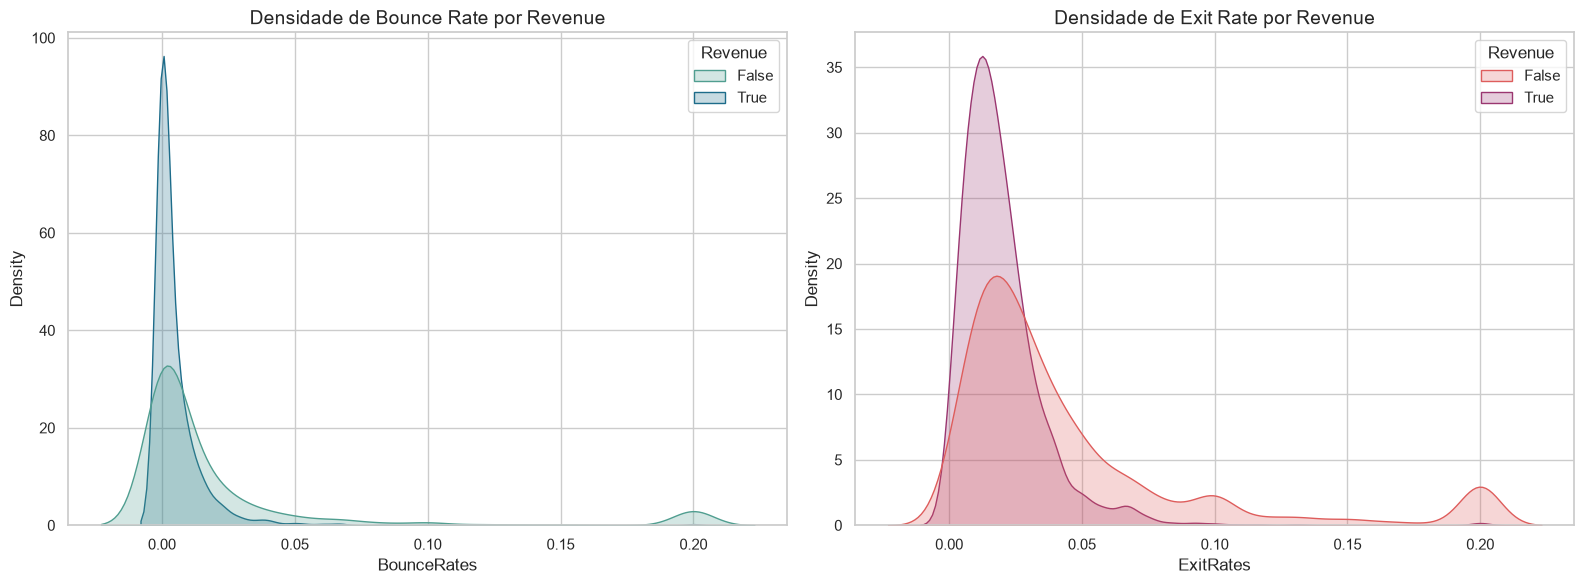

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df, x='BounceRates', hue='Revenue', fill=True, common_norm=False, palette='crest', ax=axes[0])
axes[0].set_title('Densidade de Bounce Rate por Revenue')

sns.kdeplot(data=df, x='ExitRates', hue='Revenue', fill=True, common_norm=False, palette='flare', ax=axes[1])
axes[1].set_title('Densidade de Exit Rate por Revenue')

plt.tight_layout()
plt.show()

### **4.4. Análise Temporal e Sazonalidade (Month, SpecialDay, Weekend)**

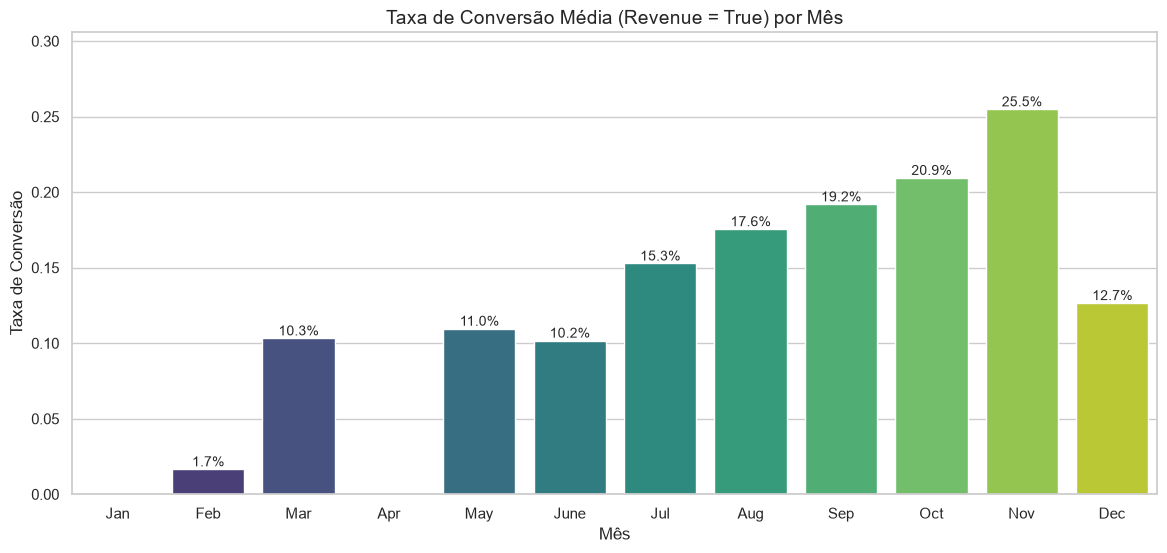

In [7]:
plt.figure(figsize=(14, 6))
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Taxa de conversão por mês
df_month = df.groupby('Month')['Revenue'].mean().reindex(month_order).reset_index()

ax = sns.barplot(x='Month', y='Revenue', data=df_month, palette='viridis')
plt.title('Taxa de Conversão Média (Revenue = True) por Mês')
plt.xlabel('Mês')
plt.ylabel('Taxa de Conversão')
plt.ylim(0, df_month['Revenue'].max() * 1.2)

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()

### **4.5. Tipos de Visitantes e Canais de Tráfego**

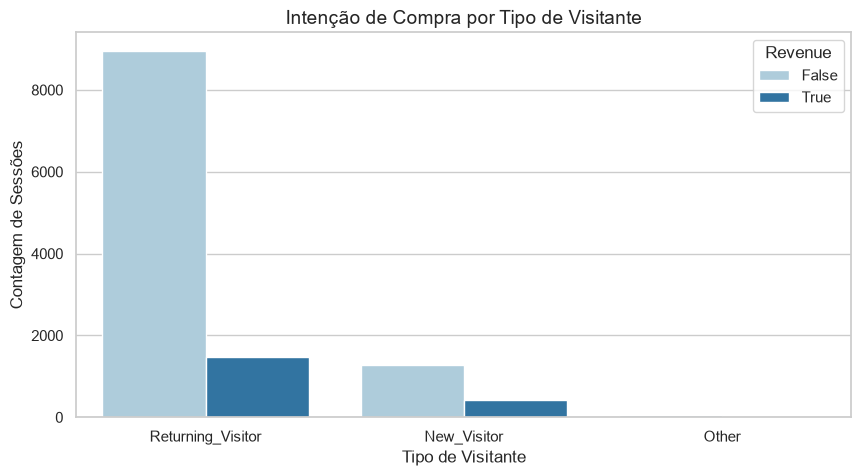

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette='Paired')
plt.title('Intenção de Compra por Tipo de Visitante')
plt.xlabel('Tipo de Visitante')
plt.ylabel('Contagem de Sessões')
plt.legend(title='Revenue')
plt.show()

## 5. Matriz de Correlação

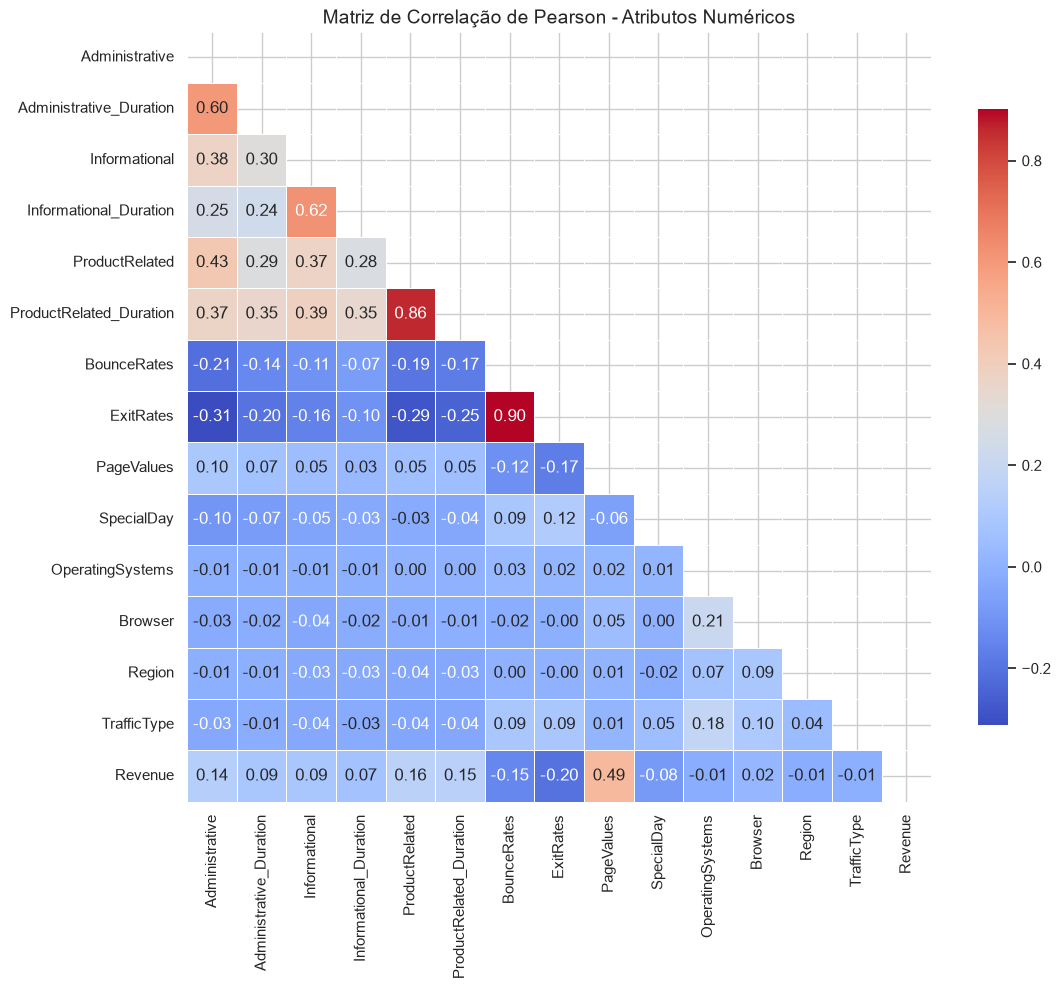

In [9]:
# Selecionando apenas colunas numéricas para a matriz de correlação
plt.figure(figsize=(12, 10))
corr_df = df.copy()
corr_df['Revenue'] = corr_df['Revenue'].astype(int)
numeric_cols = corr_df.select_dtypes(include=[np.number]).columns
corr = corr_df[numeric_cols].corr()

# Criando a máscara para o triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'shrink': .8}, linewidths=0.5)
plt.title('Matriz de Correlação de Pearson - Atributos Numéricos')
plt.show()

## 6. Conclusões e Principais Insights

Resumo dos principais achados da análise exploratória.

### Principais Insights

#### **6.1 Qualidade dos Dados**
* Dataset limpo e bem estruturado
* Nenhuma anomalia de domínio encontrada
* Linhas duplicadas devidamente removidas

#### **6.2 Variável Target (Churn)**
* **Desbalanceamento moderado:** ~15,6% de visitas convertidas em compras vs 84,4% sem conversão em compras
* **Implicação:** Requer atenção especial na modelagem (métricas, balanceamento)

#### **6.3 Multicolinearidade**
* **Correlação** entre `PageValues` e `Revenues` (~0.49)
* **Conclusão:** `PageValues` demonstra ser o preditor individual mais forte para distinguir usuários que compram daqueles que não compram
* **Conclusão 2:** Taxas de rejeição (`BouceRates`/`ExitRates`) são notavelmente menores em sessões que converteram em compras 

#### **6.4 Fator que favorecem a conversão em compras**
* **Sazonalidade:** Meses específicos (como Novembro) apresentam picos acentuados no volume de acessos e taxas de conversão
  
#### **6.5 Próximos Passos**
a. **Feature Engineering:**
   * Criar `TotalSessionTime` = Administrative_Duration + Informational_Duration + ProductRelated_Duration 
   * Criar `TotalPagesVisited` = Administrative + Informational + ProductRelated
   * Criar `AdministrativeTimeRatio` = Administrative_Duration / TotalSessionTime
   * Criar `InformationalTimeRatio` = Informational_Duration / TotalSessionTime
   * Criar `ProductRelatedTimeRatio` = ProductRelated_Duration / TotalSessionTime
   * Criar `AdministrativeRatio` = Administrative / ProductRelatedTimeRatio
   * Criar `InformationalRatio` = Informational / ProductRelatedTimeRatio
   * Criar `ProductRelatedRatio` = ProductRelated / ProductRelatedTimeRatio
   * One-hot encoding de variáveis categóricas, principalmente, `Revenue`

b. **Modelagem:**
   * Utilizar técnica de balanceamento SMOTE
   * Avaliar modelos: Random Forest, XGBoost e LightGBM
   * Usar métricas apropriadas: Precision, Recall, F1-Score, ROC-AUC e PR-AUC